In [ ]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path

# Derive repo root from this notebook's location.
# Notebooks live in Scripts/, so repo root is one level up.
# Works regardless of where Jupyter was launched from.
NOTEBOOK_DIR = Path(os.path.abspath(''))
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'Scripts' else NOTEBOOK_DIR
SCRIPT_DIR = REPO_ROOT / 'Scripts'

# Add Scripts/ to the Python path so functions.py can be imported directly,
# then set the working directory to repo root (required by functions.py for
# all relative file paths like 'fuel_energy_info/', 'Maps/', etc.)
sys.path.insert(0, str(SCRIPT_DIR))
os.chdir(REPO_ROOT)

import functions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import searoute
from tqdm import tqdm
import statsmodels.api as sm

print('Repo root:', REPO_ROOT)
print('Working directory:', os.getcwd())

/Users/aidangoldenberg-hart/Documents/MIT/Thesis/Mode-Shifting-Aidan/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Repo root: /Users/aidangoldenberg-hart/Documents/MIT/Thesis/Mode-Shifting-Aidan
Working directory: /Users/aidangoldenberg-hart/Documents/MIT/Thesis/Mode-Shifting-Aidan


### Preamble -- Calling data that will be necessary for multiple plots

In [ ]:
#### WARNING: Only run this once, otherwise the Export and Import data files will be overwritten incorrectly
#### Once you have run this once, just call the data using the all_flows.csv file this block creates.

# functions.clean_all()
# all_flows = functions.concat_all()
# all_flows.to_csv('all_flows.csv', index=False)

In [2]:
# Load the all_flows dataset
## These data represent all trade flows (imports and exports separately)
all_flows = pd.read_csv('all_flows.csv')

# Calculate emissions based on raw trade flows
all_emissions = functions.general_emissions(all_flows)

  No cache found, will create ocean_distances_cache.csv
  Total unique routes: 18942
  Already cached: 0
  Need to calculate: 18942
  Calculating 18942 new ocean routes...


  Ocean routing: 100%|██████████| 18942/18942 [03:17<00:00, 95.86it/s] 
/Users/aidangoldenberg-hart/Documents/MIT/Thesis/Mode-Shifting-Aidan/Scripts/functions.py:806: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cache_df = pd.concat([cache_df, new_cache_entries], ignore_index=True)


  Cache updated: 18942 total routes saved


/Users/aidangoldenberg-hart/Documents/MIT/Thesis/Mode-Shifting-Aidan/Scripts/functions.py:888: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['tau_binned'] = df.groupby(bins)[tau_col].transform('median')


In [3]:
# maps the code number to its name
hts_codes = {
    1:  "Live Animals",
    2:  "Meat",
    3:  "Fish",
    4:  "Dairy",
    5:  "Animal Products",
    6:  "Live Plants",
    7:  "Vegetables",
    8:  "Fruits/Nuts",
    9:  "Coffee/Tea",
    10: "Cereals",
    11: "Milling Products",
    12: "Oil Seeds",
    13: "Resins",
    14: "Vegetable Products",
    15: "Fats/Oils",
    16: "Meat Preparations",
    17: "Sugar",
    18: "Cocoa",
    19: "Baking Preparations",
    20: "Vegetable Preparations",
    21: "Misc Edible Preparations",
    22: "Beverages",
    23: "Food Waste",
    24: "Tobacco",
    25: "Stone/Salt",
    26: "Ores",
    27: "Mineral Fuels",
    28: "Inorganic Chemicals",
    29: "Organic Chemicals",
    30: "Pharmaceuticals",
    31: "Fertilizers",
    32: "Dyes/Paints",
    33: "Cosmetics",
    34: "Soap/Wax",
    35: "Enzymes",
    36: "Explosives",
    37: "Photo",
    38: "Misc Chemical Products",
    39: "Plastics",
    40: "Rubber",
    41: "Hides",
    42: "Leather",
    43: "Furs",
    44: "Wood",
    45: "Cork",
    46: "Basketry",
    47: "Wood Pulp/Paper Waste",
    48: "Paper/Paperboard",
    49: "Printed Products",
    50: "Silk",
    51: "Wool",
    52: "Cotton",
    53: "Vegetable Textile Fibers",
    54: "Manmade Filaments",
    55: "Manmade Staple Fibers",
    56: "Wadding/Rope",
    57: "Carpets/Rugs",
    58: "Special Woven Fabrics",
    59: "Covered Textiles",
    60: "Knitted Fabrics",
    61: "Apparel (Knitted)",
    62: "Apparel (Not Knitted)",
    63: "Misc Textile ",
    64: "Footwear",
    65: "Headgear",
    66: "Umbrellas",
    67: "Feathers/Human Hair",
    68: "Stone etc.",
    69: "Ceramic Products",
    70: "Glass",
    71: "Precious Metals",
    72: "Iron/Steel",
    73: "Iron/Steel Articles",
    74: "Copper",
    75: "Nickel",
    76: "Aluminum",
    78: "Lead",
    79: "Zinc",
    80: "Tin",
    81: "Other Base Metals",
    82: "Tools",
    83: "Misc Articles of Base Metal",
    84: "Mechanical Machinery",
    85: "Electrical Machinery",
    86: "Railway Equipment",
    87: "Vehicles and Parts",
    88: "Aircraft and Parts",
    89: "Ships",
    90: "Optical Instruments",
    91: "Clocks/Watches",
    92: "Musical Instruments",
    93: "Arms/Ammunition",
    94: "Furniture",
    95: "Toys",
    96: "Misc Manufactured Articles",
    97: "Works of Art",
    98: "Special Classification",
    99: "Special Import Reporting"
}


all_emissions['hts_name'] = all_emissions['hts_num'].map(hts_codes)

In [4]:
## Reads in all the 4-digit dataframes.
## The all_4digits_data.xlsx file is not included in the repo (too large for GitHub).
## Option A (default): place all_4digits_data.xlsx in the repo root and it will be loaded below.
## Option B: run the commented-out block to rebuild it from the Census API (slow but fully reproducible).

xlsx_path = REPO_ROOT / 'all_4digits_data.xlsx'

if xlsx_path.exists():
    xls = pd.ExcelFile(xlsx_path)
    all_hts_datasets = {
        sheet_name: pd.read_excel(xls, sheet_name=sheet_name)
        for sheet_name in xls.sheet_names
    }
    print(f"Loaded {len(all_hts_datasets)} HTS datasets from {xlsx_path.name}")
else:
    print(f"WARNING: {xlsx_path} not found. Running API rebuild instead (this will take a while)...")
    all_hts_datasets = {}
    for i in range(1, 100):
        code = f"{i:02d}"
        print(f"Fetching data for HTS {code}...")
        try:
            df_raw = functions.fetch_trade_data(code)
            if not df_raw:
                print(f"  No data for HTS {code}, skipping.")
                continue
            df_master = functions.build_all_master(df_raw)
            all_hts_datasets[f"all_{code}_data"] = df_master
            print(f"  Saved all_{code}_data ({len(df_master)} rows)")
        except Exception as e:
            print(f"  ERROR processing HTS {code}: {e}")

Fetching data for HTS 01...
  ERROR processing HTS 01: CENSUS_API_KEY environment variable is not set. Get a free key at https://api.census.gov/data/key_signup.html and run: export CENSUS_API_KEY='your_key_here'
Fetching data for HTS 02...
  ERROR processing HTS 02: CENSUS_API_KEY environment variable is not set. Get a free key at https://api.census.gov/data/key_signup.html and run: export CENSUS_API_KEY='your_key_here'
Fetching data for HTS 03...
  ERROR processing HTS 03: CENSUS_API_KEY environment variable is not set. Get a free key at https://api.census.gov/data/key_signup.html and run: export CENSUS_API_KEY='your_key_here'
Fetching data for HTS 04...
  ERROR processing HTS 04: CENSUS_API_KEY environment variable is not set. Get a free key at https://api.census.gov/data/key_signup.html and run: export CENSUS_API_KEY='your_key_here'
Fetching data for HTS 05...
  ERROR processing HTS 05: CENSUS_API_KEY environment variable is not set. Get a free key at https://api.census.gov/data/key

In [7]:
# runs montecarlo for HTS2

#creates the dataframe with only rows that have actual air cargo
all_non_zeronan = all_emissions[all_emissions['haversine_distance_km'].notna() & all_emissions['AIR_VAL_YR'] != 0]
HTS2_mc_results = functions.monte_carlo_transport_cost(all_non_zeronan, n_sims=5000)



## Raw Data Description (2.1.1)

In [8]:
#counting total number of rows
all_emissions['AIR_WGT_YR'].count()

#rows with aviation movement
all_emissions[all_emissions['AIR_WGT_YR'] > 0]['AIR_WGT_YR'].count()

#rows with maritime movement
all_emissions[all_emissions['VES_VAL_YR'] > 0]['VES_WGT_YR'].count()

#rows with both
all_emissions[(all_emissions['VES_WGT_YR'] > 0) & (all_emissions['AIR_WGT_YR'] > 0)]['VES_WGT_YR'].count()

#total number of countries
all_emissions['CTY_NAME'].nunique()

#total number of ports
all_emissions['PORT_NAME'].nunique()

398

In [9]:
#total maritime mass
all_emissions['VES_WGT_T'].sum()

#total aviation mass
all_emissions['AIR_WGT_T'].sum()

#ratio
all_emissions['VES_WGT_T'].sum() / all_emissions['AIR_WGT_T'].sum()

#total maritime value
all_emissions['VES_VAL_YR'].sum()

#total aviation value
all_emissions['AIR_VAL_YR'].sum()

#ratio
all_emissions['VES_VAL_YR'].sum() / all_emissions['AIR_VAL_YR'].sum()

#avg value per ton of maritime
all_emissions['VES_VAL_YR'].sum() / all_emissions['VES_WGT_T'].sum()

#avg value per ton of aviation
all_emissions['AIR_VAL_YR'].sum() / all_emissions['AIR_WGT_T'].sum()

np.float64(182486.71257927854)

In [10]:
# Maritime breakdown by flow type
import_weight_mar = all_emissions.loc[all_emissions['flow'] == 'import', 'VES_WGT_YR'].sum()
export_weight_mar = all_emissions.loc[all_emissions['flow'] == 'export', 'VES_WGT_YR'].sum()

import_value_mar = all_emissions.loc[all_emissions['flow'] == 'import', 'VES_VAL_YR'].sum()
export_value_mar = all_emissions.loc[all_emissions['flow'] == 'export', 'VES_VAL_YR'].sum()

# Aviation breakdown by flow type
import_weight_av = all_emissions.loc[all_emissions['flow'] == 'import', 'AIR_WGT_YR'].sum()
export_weight_av = all_emissions.loc[all_emissions['flow'] == 'export', 'AIR_WGT_YR'].sum()

import_value_av = all_emissions.loc[all_emissions['flow'] == 'import', 'AIR_VAL_YR'].sum()
export_value_av = all_emissions.loc[all_emissions['flow'] == 'export', 'AIR_VAL_YR'].sum()




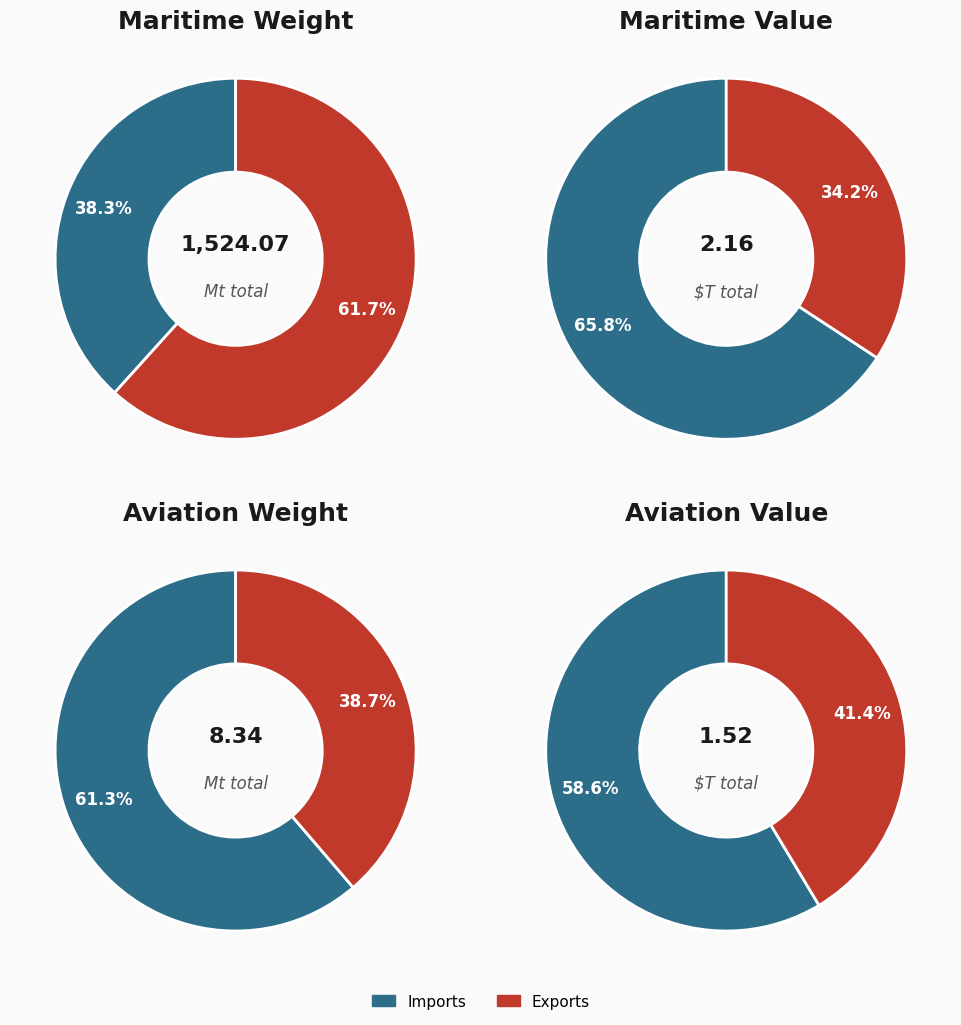

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Unit conversions ---
KG_TO_MT    = 1e-9
USD_TO_TRIL = 1e-12

# --- Style ---
plt.rcParams.update({
    'font.family':      'sans serif',
    'font.size':        11,
})

COLORS     = ['#2C6E8A', '#C0392B']
LABELS     = ['Imports', 'Exports']
EDGE_COLOR = 'white'

def donut_chart(ax, values, title, unit, fmt):
    wedges, texts, autotexts = ax.pie(
        values,
        labels=None,
        autopct='%1.1f%%',
        colors=COLORS,
        startangle=90,
        pctdistance=0.78,
        wedgeprops=dict(width=0.52, edgecolor=EDGE_COLOR, linewidth=2),
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight('bold')
        at.set_color('white')

    total = sum(values)
    ax.text(0, 0.08, f'{total:,.2f}', ha='center', va='center',
            fontsize=16, fontweight='bold', color='#1a1a1a')
    ax.text(0, -0.18, f'{unit} total', ha='center', va='center',
            fontsize=12, color='#555555', style='italic')

    ax.set_title(title, fontsize=18, fontweight='bold', pad=0, color='#1a1a1a')


datasets = [
    ([import_weight_mar * KG_TO_MT,    export_weight_mar * KG_TO_MT],
     'Maritime Weight',  'Mt'),
    ([import_value_mar  * USD_TO_TRIL, export_value_mar  * USD_TO_TRIL],
     'Maritime Value',   '$T'),
    ([import_weight_av  * KG_TO_MT,    export_weight_av  * KG_TO_MT],
     'Aviation Weight',  'Mt'),
    ([import_value_av   * USD_TO_TRIL, export_value_av   * USD_TO_TRIL],
     'Aviation Value',   '$T'),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.patch.set_facecolor('#FAFAFA')

for ax, (values, title, unit) in zip(axes.flat, datasets):
    ax.set_aspect('equal')
    donut_chart(ax, values, title, unit, None)

# Single shared legend
patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.03),
           ncol=2, frameon=False, fontsize=11, handlelength=1.5)

plt.tight_layout()
plt.savefig('Thesis_Plots/trade_balance_quad.png', dpi=200, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
# After plt.show() / plt.savefig()
plt.rcdefaults()

## Maritime Section (2.3)

In [12]:
all_emissions

,AIR_VAL_YR,AIR_WGT_YR,VES_VAL_YR,VES_WGT_YR,CNT_VAL_YR,CNT_WGT_YR,CTY_CODE,CTY_NAME,PORT_NAME,CTY_ISO3,...,AIR_WGT_T,AIR_WGT_eff,tkm_aviation_eff,tkm_aviation,kgCO2_per_tkm_air,kgCO2eq_aviation,MtCO2eq_aviation,hypo_gCO2eq_maritime,hypo_MtCO2eq_maritime,hts_name
0,0,0,8400,300,8400,300,2740,TRINIDAD AND TOBAGO,"NEW YORK, NY",TTO,...,0.000,0.0000,0.000000,0.000000,0.567981,0.000000,0.000000,0.000000e+00,0.000000e+00,Musical Instruments
1,0,0,40858,1038,40858,1038,4210,NETHERLANDS,"NEW YORK, NY",NLD,...,0.000,0.0000,0.000000,0.000000,0.591027,0.000000,0.000000,0.000000e+00,0.000000e+00,Musical Instruments
2,0,0,692168,34396,692168,34396,4280,GERMANY,"NEW YORK, NY",DEU,...,0.000,0.0000,0.000000,0.000000,0.600595,0.000000,0.000000,0.000000e+00,0.000000e+00,Musical Instruments
3,0,0,3134,52,3134,52,4359,SLOVAKIA,"NEW YORK, NY",SVK,...,0.000,0.0000,0.000000,0.000000,0.620879,0.000000,0.000000,0.000000e+00,0.000000e+00,Musical Instruments
4,0,0,380667,8025,380667,8025,4759,ITALY,"NEW YORK, NY",ITA,...,0.000,0.0000,0.000000,0.000000,0.616164,0.000000,0.000000,0.000000e+00,0.000000e+00,Musical Instruments
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362240,30583,4864,190231,50311,190231,50311,5880,JAPAN,"CHICAGO, IL",JPN,...,4.864,7.2960,73264.509606,48843.006404,0.725648,35442.815213,0.000035,4.887037e+05,4.887037e-07,Baking Preparations
362241,38337,10251,150296,51680,150296,51680,6021,AUSTRALIA,"CHICAGO, IL",AUS,...,10.251,15.3765,242688.496473,161792.330982,0.929428,150374.327297,0.000150,1.115499e+06,1.115499e-06,Baking Preparations
362242,2978,571,0,0,0,0,6141,NEW ZEALAND,"CHICAGO, IL",NZL,...,0.571,0.8565,11747.408440,7831.605626,0.857364,6714.536106,0.000007,5.369779e+04,5.369779e-08,Baking Preparations
362243,30480,13540,0,0,0,0,7530,NIGERIA,"CHICAGO, IL",NGA,...,13.540,20.3100,198330.765392,132220.510262,0.715755,94637.433513,0.000095,7.411602e+05,7.411602e-07,Baking Preparations


In [13]:
# Total maritime emissions
tot_mar_em_mt = all_emissions['MtCO2eq_maritime'].sum()

tot_mar_em_mt

np.float64(134.43557031706243)

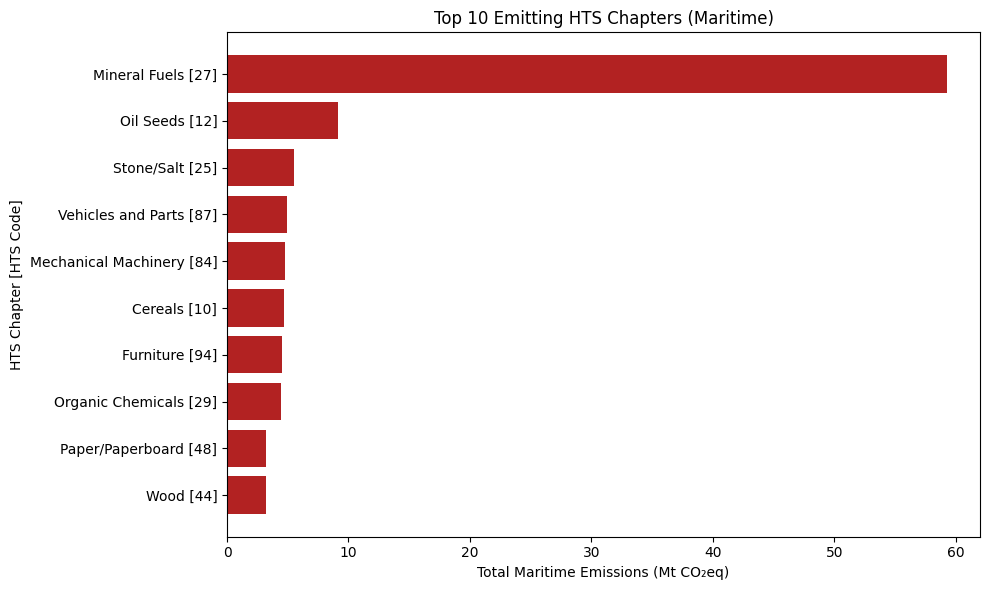

In [14]:
# Top 5 emitting HTS codes

# Aggregate total maritime emissions by HTS code
hts_maritime = (
    all_emissions
    .groupby(['hts_num', 'hts_name'], as_index=False)['MtCO2eq_maritime']
    .sum()
)

top10_maritime = (
    hts_maritime
    .sort_values('MtCO2eq_maritime', ascending=False)
    .head(10)
)

top10_maritime['label'] = (
    top10_maritime['hts_name'] + 
    " [" + top10_maritime['hts_num'].astype(str) + "]"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_maritime['label'],
    top10_maritime['MtCO2eq_maritime'],
    color = 'firebrick'
)

plt.xlabel('Total Maritime Emissions (Mt CO₂eq)')
plt.ylabel('HTS Chapter [HTS Code]')
plt.title('Top 10 Emitting HTS Chapters (Maritime)')
plt.xlim(0,62)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Thesis_Plots/top10_maritime_emissions.png')
plt.show()



In [15]:
# top 10 flows

top_10 = all_emissions.sort_values('MtCO2eq_maritime', ascending=False).head(10)

top_10[['hts_num', 'hts_name','CTY_NAME', 'PORT_NAME', 'flow', 'MtCO2eq_maritime']]

,hts_num,hts_name,CTY_NAME,PORT_NAME,flow,MtCO2eq_maritime
347216,27,Mineral Fuels,"KOREA, REPUBLIC OF","CORPUS CHRISTI, TX",export,2.255612
195417,12,Oil Seeds,CHINA,"GRAMERCY, LA",export,1.714617
195360,12,Oil Seeds,CHINA,"NEW ORLEANS, LA",export,1.536694
347188,27,Mineral Fuels,NETHERLANDS,"CORPUS CHRISTI, TX",export,1.382398
345126,27,Mineral Fuels,INDIA,"BALTIMORE, MD",export,1.244031
346948,27,Mineral Fuels,JAPAN,"HOUSTON, TX",export,1.224386
347218,27,Mineral Fuels,TAIWAN,"CORPUS CHRISTI, TX",export,1.197124
347212,27,Mineral Fuels,SINGAPORE,"CORPUS CHRISTI, TX",export,1.145266
345204,27,Mineral Fuels,INDIA,"NORFOLK-NEWPORT NEWS, VA",export,1.126971
346944,27,Mineral Fuels,CHINA,"HOUSTON, TX",export,1.090796


In [16]:
top_10['MtCO2eq_maritime'].sum()/tot_mar_em_mt

np.float64(0.1035283638454145)

In [17]:
min_plus_oil = all_emissions[all_emissions['hts_num'].isin([12, 27])]

min_plus_oil = min_plus_oil.groupby('hts_num', as_index=False)['MtCO2eq_maritime'].sum()

top2 = min_plus_oil['MtCO2eq_maritime'].sum()

print(top2/tot_mar_em_mt)
print(min_plus_oil['MtCO2eq_maritime'].iloc[0]/tot_mar_em_mt)

0.5087927613243672
0.06767126683959493


In [18]:
import_emissions = all_emissions[all_emissions['flow'] == 'import']
export_emissions = all_emissions[all_emissions['flow'] == 'export']

print(import_emissions['MtCO2eq_maritime'].sum()/tot_mar_em_mt)
print(export_emissions['MtCO2eq_maritime'].sum()/tot_mar_em_mt)

0.4052787824592524
0.5947212175407472


In [19]:
just_min = all_emissions[all_emissions['hts_num'] == 27]
just_min = just_min.groupby(['CTY_NAME', 'flow'], as_index=False)['MtCO2eq_maritime'].sum()
just_min.sort_values('MtCO2eq_maritime', ascending=False).head(10)

,CTY_NAME,flow,MtCO2eq_maritime
129,INDIA,export,5.937920
55,CHINA,export,5.020073
150,"KOREA, REPUBLIC OF",export,3.981260
192,NETHERLANDS,export,3.786186
143,JAPAN,export,3.453102
49,CANADA,import,3.231004
48,CANADA,export,2.919924
244,SINGAPORE,export,2.072195
237,SAUDI ARABIA,import,1.680828
263,TAIWAN,export,1.667012


In [20]:
all_emissions.groupby(['CTY_NAME']).agg({'MtCO2eq_maritime': 'sum'}).sort_values('MtCO2eq_maritime', ascending=False).head(20)

# all_emissions.groupby(['PORT_NAME', 'flow']).agg({'MtCO2eq_maritime': 'sum'}).sort_values('MtCO2eq_maritime', ascending=False).head(20)

,MtCO2eq_maritime
CTY_NAME,
CHINA,25.118557
CANADA,10.662965
INDIA,10.074614
"KOREA, REPUBLIC OF",8.258002
JAPAN,7.838599
VIETNAM,5.057383
NETHERLANDS,4.704197
MEXICO,4.496772
TAIWAN,3.357722


In [21]:
non_mineral_fuels = all_emissions[~all_emissions['hts_num'].isin([27])]


non_mineral_fuels.groupby(['CTY_NAME']).agg({'MtCO2eq_maritime': 'sum'}).sort_values('MtCO2eq_maritime', ascending=False).head(20)
# non_mineral_fuels.groupby(['PORT_NAME']).agg({'MtCO2eq_maritime': 'sum'}).sort_values('MtCO2eq_maritime', ascending=False).head(20)


,MtCO2eq_maritime
CTY_NAME,
CHINA,20.062168
VIETNAM,5.002561
CANADA,4.512037
JAPAN,4.342189
"KOREA, REPUBLIC OF",3.911464
INDIA,3.799528
INDONESIA,2.452831
THAILAND,2.129902
Türkiye,1.807903


## Aviation Section (2.4)

In [22]:
bjarni_data = pd.read_csv(REPO_ROOT / 'Aviation_Data' / '2024_out.csv')
bjarni_grouped = bjarni_data.groupby(['Origin.Airport', 'Destination.Airport']).agg({'Number.of.Operations': 'sum', 
                                                                     'distance(nm)': 'median',
                                                                     'total.fuel(kg)': 'sum'}).reset_index()


#stats from BTS T-100 dataset
transstats_2024 = pd.read_csv(REPO_ROOT / 'Aviation_Data' / 'T_T100I_SEGMENT_ALL_CARRIER-2.csv')

transstats_2024_grouped = transstats_2024.groupby(['ORIGIN', 'DEST']).agg({'DEPARTURES_PERFORMED': 'sum', 
                                                                     'PASSENGERS': 'sum',
                                                                     'SEATS': 'sum',
                                                                     'FREIGHT': 'sum'}).reset_index()

combined = pd.merge(bjarni_grouped, transstats_2024_grouped, left_on=['Origin.Airport', 'Destination.Airport'], right_on=['ORIGIN', 'DEST'], how='inner')

combined = combined[combined['distance(nm)'] > 0]


combined['departure_diff_pct'] = (
    abs(combined['Number.of.Operations'] - combined['DEPARTURES_PERFORMED']) /
    ((combined['Number.of.Operations'] + combined['DEPARTURES_PERFORMED']) / 2)
)

combined = combined[combined['departure_diff_pct'] < 0.3]

combined['PASS_WGT_KG'] = combined['PASSENGERS'] * 100  # Assuming average passenger weight is 100 kg
combined['FREIGHT_KG'] = combined['FREIGHT'] / 2.205  # Convert pounds to kg
combined['SEATS_WGT_KG'] = combined['SEATS'] * 50  # Assuming average seat weight is 50 kg
combined['TOTAL_PAYLOAD_KG'] = combined['PASS_WGT_KG'] + combined['FREIGHT_KG'] + combined['SEATS_WGT_KG']
combined['distance(km)'] = combined['distance(nm)'] * 1.852  # Convert nautical miles to kilometers
combined['total_tkm'] = combined['TOTAL_PAYLOAD_KG'] * combined['distance(km)'] / 1000  # Convert kg-km to tonne-km
combined['wtw_emissions_kg'] = combined['total.fuel(kg)'] * 3.84  # Using the same emission factor as before
combined['kgco2_per_tkm'] = combined['wtw_emissions_kg'] / combined['total_tkm']

combined = combined[combined['TOTAL_PAYLOAD_KG'] > 0]
combined = combined[combined['kgco2_per_tkm'] < 50] # removes remaining large outliers

/var/folders/gz/8_90lc557cz2m5ng9pljq3d00000gn/T/ipykernel_74302/976150119.py:1: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  bjarni_data = pd.read_csv(REPO_ROOT / 'Aviation_Data' / '2024_out.csv')


                            OLS Regression Results                            
Dep. Variable:          kgco2_per_tkm   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     798.5
Date:                Thu, 07 May 2026   Prob (F-statistic):          3.14e-278
Time:                        16:45:28   Log-Likelihood:                -812.31
No. Observations:                2973   AIC:                             1631.
Df Residuals:                    2970   BIC:                             1649.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              14.7485      0.394     

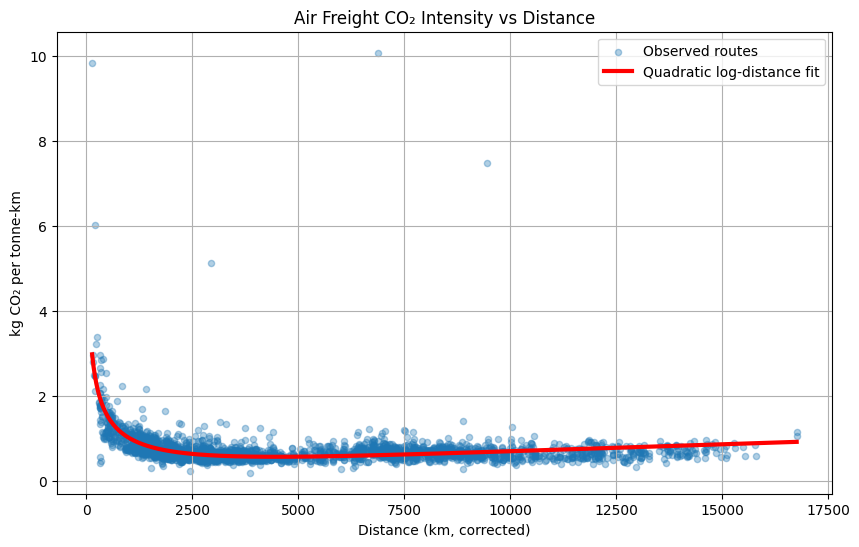

In [23]:

# --- Apply distance detour correction ---
combined['distance_corrected_km'] = combined['distance(km)'] * 1.09

# --- Prepare regression variables ---
combined["log_distance"] = np.log(combined["distance_corrected_km"])
combined["log_distance_sq"] = combined["log_distance"] ** 2

# --- Fit quadratic log-distance model ---
X = sm.add_constant(combined[["log_distance", "log_distance_sq"]])
y = combined["kgco2_per_tkm"]

model = sm.OLS(y, X).fit()

print(model.summary())

# --- Create smooth curve for plotting ---
dist_curve = np.linspace(
    combined["distance_corrected_km"].min(),
    combined["distance_corrected_km"].max(),
    500
)

log_curve = np.log(dist_curve)
log_curve_sq = log_curve ** 2

X_curve = sm.add_constant(
    np.column_stack([log_curve, log_curve_sq])
)

y_curve = model.predict(X_curve)

# --- Plot results ---
plt.figure(figsize=(10,6))

plt.scatter(
    combined["distance_corrected_km"],
    combined["kgco2_per_tkm"],
    alpha=0.35,
    s=20,
    label="Observed routes"
)

plt.plot(
    dist_curve,
    y_curve,
    linewidth=3,
    label="Quadratic log-distance fit",
    color="red"
)

plt.xlabel("Distance (km, corrected)")
plt.ylabel("kg CO₂ per tonne-km")
plt.title("Air Freight CO₂ Intensity vs Distance")
plt.grid(True)
plt.legend()
plt.savefig('Thesis_Plots/aviation_intensity_regression.png')
plt.show()

In [24]:
tot_av_em_mt = all_emissions['MtCO2eq_aviation'].sum()

tot_av_em_mt

np.float64(52.96041817237866)

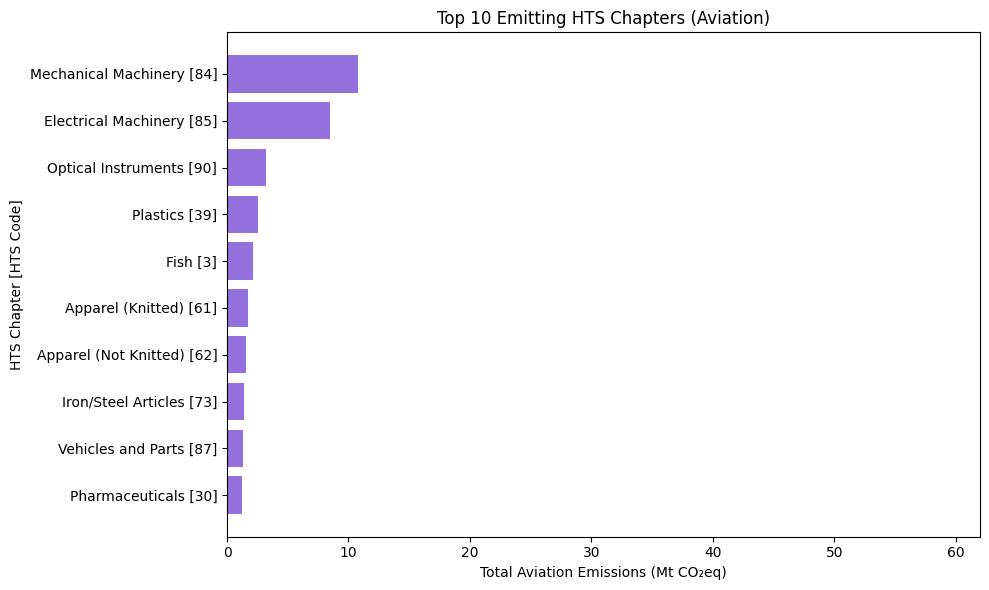

In [25]:
# Top 5 emitting HTS codes

# Aggregate total aviation emissions by HTS code
hts_aviation = (
    all_emissions
    .groupby(['hts_num', 'hts_name'], as_index=False)['MtCO2eq_aviation']
    .sum()
)

top10_aviation = (
    hts_aviation
    .sort_values('MtCO2eq_aviation', ascending=False)
    .head(10)
)

top10_aviation['label'] = (
    top10_aviation['hts_name'] + 
    " [" + top10_aviation['hts_num'].astype(str) + "]"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_aviation['label'],
    top10_aviation['MtCO2eq_aviation'],
    color = 'mediumpurple'
)

plt.xlabel('Total Aviation Emissions (Mt CO₂eq)')
plt.ylabel('HTS Chapter [HTS Code]')
plt.title('Top 10 Emitting HTS Chapters (Aviation)')
plt.xlim(0,62)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Thesis_Plots/top10_aviation_emissions.png')
plt.show()



In [26]:
machinery = all_emissions[all_emissions['hts_num'].isin([84, 85])]

machinery = machinery.groupby('hts_num', as_index=False)['MtCO2eq_aviation'].sum()

top2 = machinery['MtCO2eq_aviation'].sum()

print(top2/tot_mar_em_mt)
print(machinery['MtCO2eq_aviation'].iloc[1]/tot_mar_em_mt)

0.14331431738556424
0.06291491165990357


In [27]:
# top 10 flows

top_10 = all_emissions.sort_values('MtCO2eq_aviation', ascending=False).head(10)

top_10[['hts_num', 'hts_name','CTY_NAME', 'PORT_NAME', 'flow', 'MtCO2eq_aviation']]

,hts_num,hts_name,CTY_NAME,PORT_NAME,flow,MtCO2eq_aviation
19342,85,Electrical Machinery,CHINA,"CHICAGO, IL",import,0.922550
35724,84,Mechanical Machinery,CHINA,"CHICAGO, IL",import,0.690285
127861,3,Fish,CHILE,"MIAMI INTERNATIONAL AIRPORT, FL",import,0.609537
105547,6,Live Plants,COLOMBIA,"MIAMI INTERNATIONAL AIRPORT, FL",import,0.377309
35716,84,Mechanical Machinery,VIETNAM,"CHICAGO, IL",import,0.367724
31514,84,Mechanical Machinery,CHINA,"LOS ANGELES INTERNATIONAL AIRPORT, CA",import,0.365237
15455,85,Electrical Machinery,CHINA,"LOS ANGELES INTERNATIONAL AIRPORT, CA",import,0.353672
87911,24,Tobacco,CHINA,"CHICAGO, IL",import,0.255714
19333,85,Electrical Machinery,VIETNAM,"CHICAGO, IL",import,0.240408
35728,84,Mechanical Machinery,TAIWAN,"CHICAGO, IL",import,0.218485


In [28]:
just_machinery = all_emissions[all_emissions['hts_num'].isin([84, 85])]
just_machinery = just_machinery.groupby(['PORT_NAME', 'flow'], as_index=False)['MtCO2eq_aviation'].sum()
just_machinery.sort_values('MtCO2eq_aviation', ascending=False).head(10)

,PORT_NAME,flow,MtCO2eq_aviation
120,"CHICAGO, IL",import,3.739280
330,"LOS ANGELES INTERNATIONAL AIRPORT, CA",import,1.733289
119,"CHICAGO, IL",export,1.176633
35,"ATLANTA, GA",import,0.908678
550,"SAN FRANCISCO INTERNATIONAL AIRPORT, CA",import,0.851670
291,"JFK INTERNATIONAL AIRPORT, NY",import,0.791498
127,"CLEVELAND, OH",import,0.723088
290,"JFK INTERNATIONAL AIRPORT, NY",export,0.638948
141,"DALLAS-FORT WORTH, TX",import,0.623688
329,"LOS ANGELES INTERNATIONAL AIRPORT, CA",export,0.617544


In [29]:
all_emissions.groupby(['CTY_NAME']).agg({'MtCO2eq_aviation': 'sum'}).sort_values('MtCO2eq_aviation', ascending=False).head(20)

all_emissions.groupby(['PORT_NAME', 'flow', 'hts_num']).agg({'MtCO2eq_aviation': 'sum'}).sort_values('MtCO2eq_aviation', ascending=False).head(20)

MtCO2eq_aviation
PORT_NAME                               flow   hts_num                  
CHICAGO, IL                             import 84               1.930792
                                               85               1.808488
LOS ANGELES INTERNATIONAL AIRPORT, CA   import 84               0.876744
                                               85               0.856545
MIAMI INTERNATIONAL AIRPORT, FL         import 3                0.813218
CHICAGO, IL                             export 84               0.787329
MIAMI INTERNATIONAL AIRPORT, FL         import 6                0.599906
ATLANTA, GA                             import 84               0.558513
LOS ANGELES INTERNATIONAL AIRPORT, CA   export 8                0.495259
SAN FRANCISCO INTERNATIONAL AIRPORT, CA import 84               0.493188
JFK INTERNATIONAL AIRPORT, NY           export 84               0.445161
                                        import 62               0.419445
                                               84               0.415692
CLEVELAND, OH                           import 85               0.398620
CHICAGO, IL                             export 85               0.389304
JFK INTERNATIONAL AIRPORT, NY           import 85               0.375806
CHICAGO, IL                             export 90               0.361558
LOS ANGELES INTERNATIONAL AIRPORT, CA   import 3                0.359576
SAN FRANCISCO INTERNATIONAL AIRPORT, CA import 85               0.358482
CLEVELAND, OH                           export 84               0.355319

In [30]:
non_machinery = all_emissions[~all_emissions['hts_num'].isin([84, 85])]


non_machinery.groupby(['CTY_NAME']).agg({'MtCO2eq_aviation': 'sum'}).sort_values('MtCO2eq_aviation', ascending=False).head(20)
# non_machinery.groupby(['PORT_NAME']).agg({'MtCO2eq_aviation': 'sum'}).sort_values('MtCO2eq_aviation', ascending=False).head(20)


,MtCO2eq_aviation
CTY_NAME,
CHINA,6.184605
INDIA,2.232931
JAPAN,1.751939
GERMANY,1.665327
VIETNAM,1.217672
"KOREA, REPUBLIC OF",1.216036
SINGAPORE,1.160768
UNITED KINGDOM,1.116962
ITALY,1.070279


### Comparative Discussion

In [31]:
total_tkm_mar = all_emissions['tkm_container'].sum() + all_emissions['tkm_noncontainer'].sum()
total_tkm_av = all_emissions['tkm_aviation'].sum()

mar_intensity = (tot_mar_em_mt * 1e9) / total_tkm_mar
av_intensity = (tot_av_em_mt * 1e9) / total_tkm_av

print("Maritime Emissions Intensity (kg CO₂eq per tkm):", mar_intensity)
print("Aviation Emissions Intensity (kg CO₂eq per tkm):", av_intensity)
print("Ratio aviation intensity to maritime intensity:", av_intensity / mar_intensity)

Maritime Emissions Intensity (kg CO₂eq per tkm): 0.00665976129702774
Aviation Emissions Intensity (kg CO₂eq per tkm): 0.7356179076366124
Ratio aviation intensity to maritime intensity: 110.45709820934867


In [32]:
# if all aviation tkm went on maritime

av_hypothetical = mar_intensity * total_tkm_av * 1e-9

print("Hypothetical Aviation Emissions if on Maritime (Mt CO₂eq):", av_hypothetical)

Hypothetical Aviation Emissions if on Maritime (Mt CO₂eq): 0.4794659558410914


make sure to double check this below and change the colors so that they match the other bar chart too

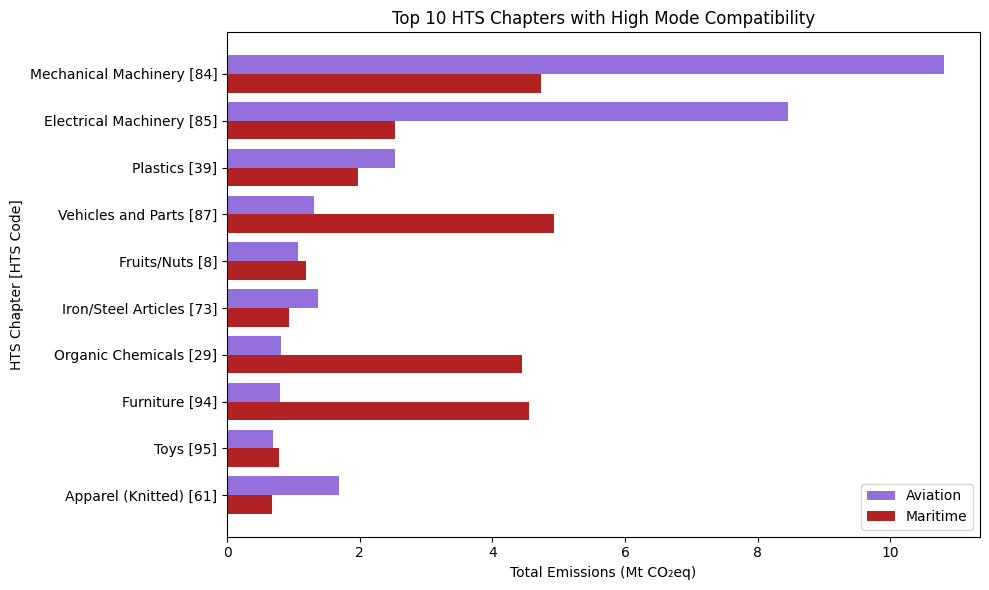

In [33]:
# Aggregate total emissions by HTS code for both modes
hts_modes = (
    all_emissions
    .groupby(['hts_num', 'hts_name'], as_index=False)[
        ['MtCO2eq_aviation', 'MtCO2eq_maritime']
    ]
    .sum()
)

# Define compatibility 
hts_modes['compatibility'] = hts_modes[
    ['MtCO2eq_aviation', 'MtCO2eq_maritime']
].min(axis=1)

# Select top 10 compatible chapters
top10_compatible = (
    hts_modes
    .sort_values('compatibility', ascending=False)
    .head(10)
)

# Create labels
top10_compatible['label'] = (
    top10_compatible['hts_name'] + 
    " [" + top10_compatible['hts_num'].astype(str) + "]"
)

# --- Plot side-by-side horizontal bars ---
import numpy as np

y = np.arange(len(top10_compatible))
bar_height = 0.4

plt.figure(figsize=(10, 6))

# Aviation bars
plt.barh(
    y - bar_height/2,
    top10_compatible['MtCO2eq_aviation'],
    height=bar_height,
    label='Aviation',
    color='mediumpurple'
)

# Maritime bars
plt.barh(
    y + bar_height/2,
    top10_compatible['MtCO2eq_maritime'],
    height=bar_height,
    label='Maritime',
    color='firebrick'
)

plt.yticks(y, top10_compatible['label'])

plt.xlabel('Total Emissions (Mt CO₂eq)')
plt.ylabel('HTS Chapter [HTS Code]')
plt.title('Top 10 HTS Chapters with High Mode Compatibility')

plt.legend()

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Thesis_Plots/top10_mode_compatibility_sidebyside.png')
plt.show()

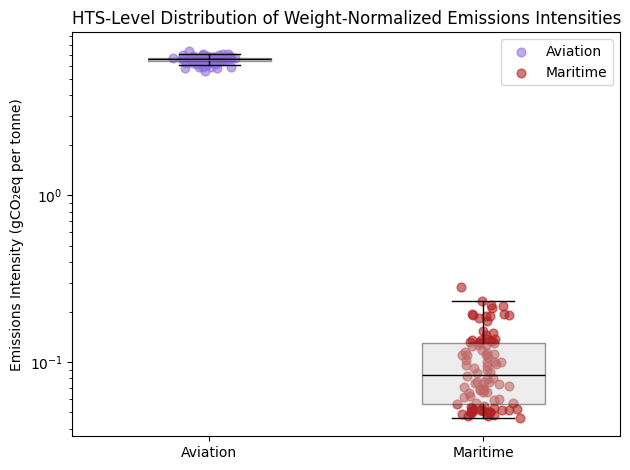

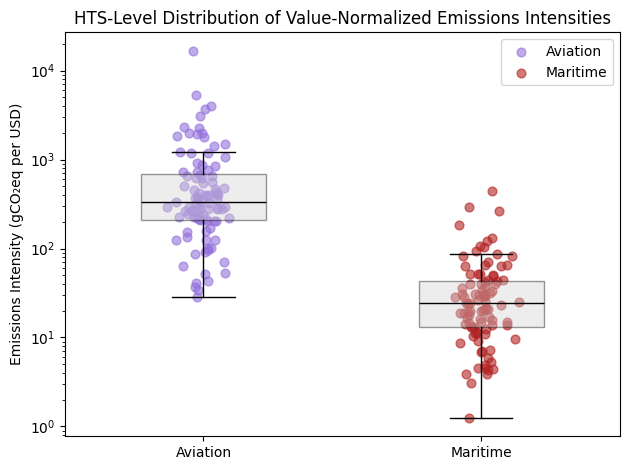

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Create emissions intensity metrics
# -------------------------------------------------

# Weight-normalized intensity
all_emissions['aviation_gCO2_per_tonne'] = (
    all_emissions['MtCO2eq_aviation'] * 1e12
    / all_emissions['AIR_WGT_YR'] / 1000
)

all_emissions['maritime_gCO2_per_tonne'] = (
    all_emissions['MtCO2eq_maritime'] * 1e12
    / all_emissions['VES_WGT_YR'] / 1000
)

# Value-normalized intensity
all_emissions['aviation_gCO2_per_dollar'] = (
    all_emissions['MtCO2eq_aviation'] * 1e12
    / all_emissions['AIR_VAL_YR']
)

all_emissions['maritime_gCO2_per_dollar'] = (
    all_emissions['MtCO2eq_maritime'] * 1e12
    / all_emissions['VES_VAL_YR']
)

# -------------------------------------------------
# Aggregate to HTS chapter level
# -------------------------------------------------

hts_metrics = (
    all_emissions
    .groupby(['hts_num', 'hts_name'], as_index=False)
    .agg({
        'aviation_gCO2_per_tonne': 'mean',
        'maritime_gCO2_per_tonne': 'mean',
        'aviation_gCO2_per_dollar': 'mean',
        'maritime_gCO2_per_dollar': 'mean'
    })
)

# -------------------------------------------------
# Clean data
# -------------------------------------------------

hts_metrics = (
    hts_metrics
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# -------------------------------------------------
# Create jittered x positions
# -------------------------------------------------

np.random.seed(42)


aviation_x = np.random.normal(0, 0.02, size=len(hts_metrics))
maritime_x = np.random.normal(0.4, 0.02, size=len(hts_metrics))

# =================================================
# PLOT 1:
# Emissions intensity per tonne
# ================================================


# -----------------------------
# BOX PLOT (background layer)
# -----------------------------
plt.boxplot(
    [
        hts_metrics['aviation_gCO2_per_tonne'],
        hts_metrics['maritime_gCO2_per_tonne']
    ],
    positions=[0, 0.4],
    widths=0.18,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey', alpha=0.4),
    medianprops=dict(color='black')
)

# -----------------------------
# SCATTER CLOUD (foreground)
# -----------------------------

plt.scatter(
    aviation_x,
    hts_metrics['aviation_gCO2_per_tonne'],
    alpha=0.6,
    s=40,
    label='Aviation',
    color='mediumpurple'
)

plt.scatter(
    maritime_x,
    hts_metrics['maritime_gCO2_per_tonne'],
    alpha=0.6,
    s=40,
    label='Maritime',
    color='firebrick'
)

# -----------------------------
# FORMATTING
# -----------------------------

plt.yscale('log')

plt.xticks([0, 0.4], ['Aviation', 'Maritime'])
plt.xlim(-0.2, 0.6)

plt.ylabel('Emissions Intensity (gCO₂eq per tonne)')
plt.title('HTS-Level Distribution of Weight-Normalized Emissions Intensities')

plt.legend()

plt.tight_layout()
plt.savefig('Thesis_Plots/hts_box_cloud_per_tonne.png')
plt.show()

# =================================================
# PLOT 2:
# Emissions intensity per dollar
# =================================================


# plt.figure(figsize=(8, 6))

# -----------------------------
# BOX PLOT (background layer)
# -----------------------------
plt.boxplot(
    [
        hts_metrics['aviation_gCO2_per_dollar'],
        hts_metrics['maritime_gCO2_per_dollar']
    ],
    positions=[0, 0.4],
    widths=0.18,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey', alpha=0.4),
    medianprops=dict(color='black')
)

# -----------------------------
# SCATTER CLOUD (foreground)
# -----------------------------

plt.scatter(
    aviation_x,
    hts_metrics['aviation_gCO2_per_dollar'],
    alpha=0.6,
    s=40,
    label='Aviation',
    color='mediumpurple'
)

plt.scatter(
    maritime_x,
    hts_metrics['maritime_gCO2_per_dollar'],
    alpha=0.6,
    s=40,
    label='Maritime',
    color='firebrick'
)

# -----------------------------
# FORMATTING
# -----------------------------

plt.yscale('log')

plt.xticks([0, 0.4], ['Aviation', 'Maritime'])
plt.xlim(-0.2, 0.6)

plt.ylabel('Emissions Intensity (gCO₂eq per USD)')
plt.title('HTS-Level Distribution of Value-Normalized Emissions Intensities')

plt.legend()

plt.tight_layout()
plt.savefig('Thesis_Plots/hts_box_cloud_per_dollar.png')
plt.show()

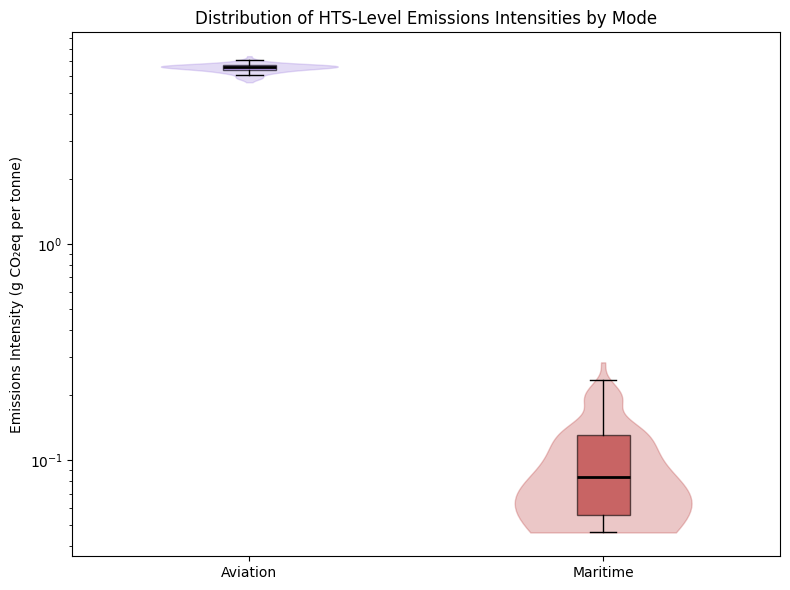

In [35]:
import matplotlib.pyplot as plt
import numpy as np

aviation = hts_metrics['aviation_gCO2_per_tonne'].replace([np.inf, -np.inf], np.nan).dropna()
maritime = hts_metrics['maritime_gCO2_per_tonne'].replace([np.inf, -np.inf], np.nan).dropna()

data = [aviation, maritime]

# -------------------------------------------------
# Figure
# -------------------------------------------------

plt.figure(figsize=(8, 6))

# -------------------------------------------------
# VIOLIN (distribution shape)
# -------------------------------------------------

parts = plt.violinplot(
    data,
    positions=[0, 1],
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Color violins
violin_colors = ['mediumpurple', 'firebrick']

for pc, color in zip(parts['bodies'], violin_colors):
    pc.set_facecolor(color)
    pc.set_edgecolor(color)
    pc.set_alpha(0.25)

# -------------------------------------------------
# BOX PLOT (summary stats overlay)
# -------------------------------------------------

box = plt.boxplot(
    data,
    positions=[0, 1],
    widths=0.15,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)

# Color box fills
box_colors = ['mediumpurple', 'firebrick']

for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)

# -------------------------------------------------
# FORMATTING
# -------------------------------------------------

plt.yscale('log')

plt.xticks([0, 1], ['Aviation', 'Maritime'])

plt.ylabel('Emissions Intensity (g CO₂eq per tonne)')
plt.title('Distribution of HTS-Level Emissions Intensities by Mode')

plt.tight_layout()
plt.savefig('Thesis_Plots/violin_box_per_tonne.png', dpi=300)
plt.show()

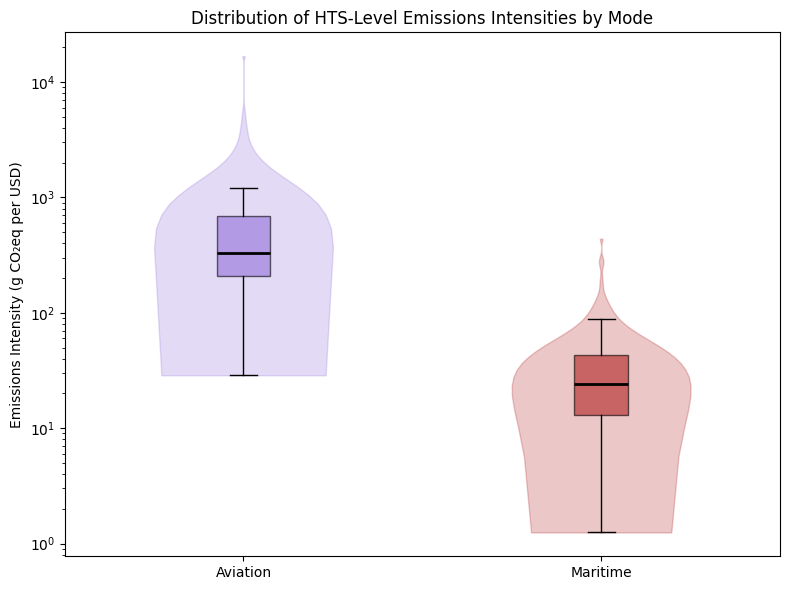

In [36]:
aviation = hts_metrics['aviation_gCO2_per_dollar'].replace([np.inf, -np.inf], np.nan).dropna()
maritime = hts_metrics['maritime_gCO2_per_dollar'].replace([np.inf, -np.inf], np.nan).dropna()

data = [aviation, maritime]

# -------------------------------------------------
# Figure
# -------------------------------------------------

plt.figure(figsize=(8, 6))

# -------------------------------------------------
# VIOLIN (distribution shape)
# -------------------------------------------------

parts = plt.violinplot(
    data,
    positions=[0, 1],
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Color violins
violin_colors = ['mediumpurple', 'firebrick']

for pc, color in zip(parts['bodies'], violin_colors):
    pc.set_facecolor(color)
    pc.set_edgecolor(color)
    pc.set_alpha(0.25)

# -------------------------------------------------
# BOX PLOT (summary stats overlay)
# -------------------------------------------------

box = plt.boxplot(
    data,
    positions=[0, 1],
    widths=0.15,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)

# Color box fills
box_colors = ['mediumpurple', 'firebrick']

for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)

# -------------------------------------------------
# FORMATTING
# -------------------------------------------------

plt.yscale('log')

plt.xticks([0, 1], ['Aviation', 'Maritime'])

plt.ylabel('Emissions Intensity (g CO₂eq per USD)')
plt.title('Distribution of HTS-Level Emissions Intensities by Mode')

plt.tight_layout()
plt.savefig('Thesis_Plots/violin_box_per_dollar.png', dpi=300)
plt.show()

In [37]:
hts_metrics

,hts_num,hts_name,aviation_gCO2_per_tonne,maritime_gCO2_per_tonne,aviation_gCO2_per_dollar,maritime_gCO2_per_dollar
0,1,Live Animals,6.129685,0.094610,171.285909,42.038769
1,2,Meat,6.903468,0.137199,880.972835,65.832758
2,3,Fish,6.422971,0.154632,650.630706,40.033757
3,4,Dairy,6.782576,0.130992,1060.215199,51.738351
4,5,Animal Products,6.467971,0.071275,279.005233,30.679189
...,...,...,...,...,...,...
92,94,Furniture,6.663609,0.233929,353.292217,51.118838
93,95,Toys,6.785917,0.125242,223.610358,17.789867
94,96,Misc Manufactured Articles,6.642760,0.110741,214.402958,18.826995
95,97,Works of Art,6.394165,0.076593,34.510076,11.306323


## Mode Shift (Ch 3)

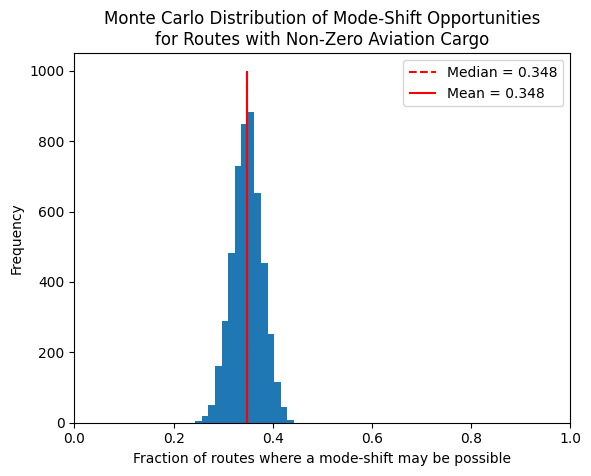

In [38]:
# general, system-level mode shifting plots

plt.figure()
plt.hist(HTS2_mc_results['mode_shift_opp_share'], bins=15)
plt.vlines(
    HTS2_mc_results['mode_shift_opp_share'].quantile(0.5),
    ymin=0,
    ymax=1000,
    colors='red',
    linestyles='dashed',
    label='Median = {:.3f}'.format(HTS2_mc_results['mode_shift_opp_share'].quantile(0.5))
)
plt.vlines(
    HTS2_mc_results['mode_shift_opp_share'].mean(),
    ymin=0,
    ymax=1000,
    colors='red',
    label='Mean = {:.3f}'.format(HTS2_mc_results['mode_shift_opp_share'].mean())
)
plt.xlabel('Fraction of routes where a mode-shift may be possible')
plt.ylabel('Frequency')
plt.title('Monte Carlo Distribution of Mode-Shift Opportunities\nfor Routes with Non-Zero Aviation Cargo')
plt.xlim(0, 1)
plt.legend()
plt.savefig("Thesis_Plots/system_monte_carlo.png")
plt.show()


In [39]:
# total # of mode shift rows
len(all_non_zeronan)*HTS2_mc_results['mode_shift_opp_share'].quantile(0.5)

np.float64(27976.500000000004)

In [40]:
# Reconstruct the exact transport-cost outcome at the median simulation.
# error_draws must use the same seed as the median sim so the result
# matches that specific Monte Carlo run.

hts2_median_share = HTS2_mc_results['mode_shift_opp_share'].median()

hts2_median_sim_idx = (
    HTS2_mc_results.assign(diff=lambda x: (x['mode_shift_opp_share'] - hts2_median_share).abs())
      .sort_values('diff')
      .iloc[0]['sim']
)

median_params = HTS2_mc_results.loc[HTS2_mc_results['sim'] == hts2_median_sim_idx].iloc[0]

hts_error_map = all_non_zeronan[['hts_num', 'error_i']].drop_duplicates().set_index('hts_num')['error_i']
unique_errors = hts_error_map.values
np.random.seed(int(hts2_median_sim_idx))
error_draws_baseline = np.random.choice(unique_errors, size=len(all_non_zeronan), replace=True)

baseline_air_cheaper_median = functions.total_transport_cost(
    all_non_zeronan,
    av_cost=median_params['av_cost'],
    mar_cost=median_params['mar_cost'],
    mar_speed=median_params['mar_speed'],
    av_speed=800,
    error_draws=error_draws_baseline,
    scc=0.0,
)

baseline_air_cheaper_median[['hts_num', 'AIR_VAL_YR', 'AIR_WGT_YR',
                              'MtCO2eq_maritime', 'MtCO2eq_aviation',
                              'hypo_MtCO2eq_maritime', 'mode_shift_opportunity']]

,hts_num,AIR_VAL_YR,AIR_WGT_YR,MtCO2eq_maritime,MtCO2eq_aviation,hypo_MtCO2eq_maritime,mode_shift_opportunity
15,92,5591,215,3.092160e-09,7.852530e-07,5.259608e-09,1
18,92,7925,17,0.000000e+00,6.645261e-08,6.058982e-10,0
19,92,2715,309,1.109135e-07,1.109436e-06,8.902814e-09,1
22,92,229291,454,4.620001e-07,1.586107e-06,1.270523e-08,0
28,92,3257,2,9.100424e-08,8.809316e-09,7.696570e-11,0
...,...,...,...,...,...,...,...
362236,19,175483,24003,0.000000e+00,2.067796e-04,2.619245e-06,0
362239,19,89603,20818,0.000000e+00,2.027040e-04,2.257734e-06,0
362240,19,30583,4864,7.582392e-06,3.544282e-05,4.887037e-07,0
362241,19,38337,10251,8.435618e-06,1.503743e-04,1.115499e-06,1


In [41]:
mode_shift_rows = baseline_air_cheaper_median[baseline_air_cheaper_median['mode_shift_opportunity'] == 1]

carbon_savings = (mode_shift_rows['MtCO2eq_aviation'] - mode_shift_rows['hypo_MtCO2eq_maritime']).sum()

print(f"Potential carbon savings: {carbon_savings:.4f} MtCO2eq")

Potential carbon savings: 9.2870 MtCO2eq


In [42]:
from tqdm import tqdm

# ── Compute carbon savings across all Monte Carlo simulations ──────────────

carbon_savings_all = []

for _, sim_row in tqdm(HTS2_mc_results.iterrows(), total=len(HTS2_mc_results), desc="Running simulations"):
    sim_idx = sim_row['sim']

    # Reconstruct the exact error draws used in this simulation
    np.random.seed(int(sim_idx))
    error_draws = np.random.choice(unique_errors, size=len(all_non_zeronan), replace=True)

    result = functions.total_transport_cost(
        all_non_zeronan,
        av_cost=sim_row['av_cost'],
        mar_cost=sim_row['mar_cost'],
        mar_speed=sim_row['mar_speed'],
        av_speed=800,
        error_draws=error_draws,
        scc=0.0,
    )

    mode_shift_rows = result[result['mode_shift_opportunity'] == 1]
    savings = (mode_shift_rows['MtCO2eq_aviation'] - mode_shift_rows['hypo_MtCO2eq_maritime']).sum()

    carbon_savings_all.append({'sim': sim_idx, 'carbon_savings': savings})

carbon_savings_df = pd.DataFrame(carbon_savings_all)

# ── Extract point estimate and 95% CI ─────────────────────────────────────

p05 = carbon_savings_df['carbon_savings'].quantile(0.05)
p50 = carbon_savings_df['carbon_savings'].quantile(0.50)
p95 = carbon_savings_df['carbon_savings'].quantile(0.95)

print(f"Potential carbon savings (median):       {p50:.4f} MtCO2eq")
print(f"95% confidence interval:                 [{p05:.4f}, {p95:.4f}] MtCO2eq")

Running simulations: 100%|██████████| 5000/5000 [01:59<00:00, 41.92it/s]

Potential carbon savings (median):       10.0745 MtCO2eq
95% confidence interval:                 [8.3801, 11.7792] MtCO2eq


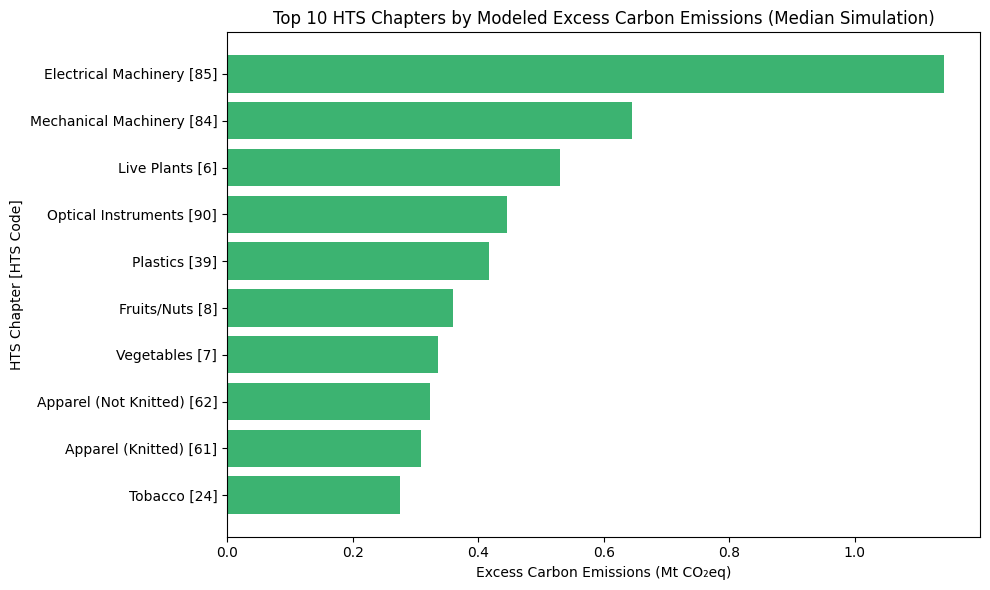

In [43]:
# Aggregate carbon savings potential by HTS code (median simulation)
hts_savings = (
    baseline_air_cheaper_median[baseline_air_cheaper_median['mode_shift_opportunity'] == 1]
    .assign(carbon_savings=lambda x: x['MtCO2eq_aviation'] - x['hypo_MtCO2eq_maritime'])
    .groupby(['hts_num', 'hts_name'], as_index=False)['carbon_savings']
    .sum()
)

top10_savings = (
    hts_savings
    .sort_values('carbon_savings', ascending=False)
    .head(10)
)

top10_savings['label'] = (
    top10_savings['hts_name'] +
    " [" + top10_savings['hts_num'].astype(str) + "]"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10_savings['label'],
    top10_savings['carbon_savings'],
    color='mediumseagreen'
)

plt.xlabel('Excess Carbon Emissions (Mt CO₂eq)')
plt.ylabel('HTS Chapter [HTS Code]')
plt.title('Top 10 HTS Chapters by Modeled Excess Carbon Emissions (Median Simulation)')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Thesis_Plots/top10_mode_shift_savings.png')
plt.show()

In [44]:
top10_savings

,hts_num,hts_name,carbon_savings,label
83,85,Electrical Machinery,1.142329,Electrical Machinery [85]
82,84,Mechanical Machinery,0.644515,Mechanical Machinery [84]
5,6,Live Plants,0.529757,Live Plants [6]
88,90,Optical Instruments,0.446115,Optical Instruments [90]
38,39,Plastics,0.416987,Plastics [39]
7,8,Fruits/Nuts,0.359212,Fruits/Nuts [8]
6,7,Vegetables,0.336478,Vegetables [7]
61,62,Apparel (Not Knitted),0.323302,Apparel (Not Knitted) [62]
60,61,Apparel (Knitted),0.308404,Apparel (Knitted) [61]
23,24,Tobacco,0.274930,Tobacco [24]


In [ ]:
import matplotlib as mpl

# Reset matplotlib settings to default
mpl.rcParams.update(mpl.rcParamsDefault)

# Increase font sizes
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# Split dataframe by mode shift opportunity
mode_shift = baseline_air_cheaper_median[
    baseline_air_cheaper_median['mode_shift_opportunity'] == 1
]

non_mode_shift = baseline_air_cheaper_median[
    baseline_air_cheaper_median['mode_shift_opportunity'] == 0
]

# Conversion factor to millions of dollars
MILLION = 1e6

# ---- Actual costs ----
actual_non_direct = non_mode_shift['direct_transport_cost_av'].mean() / MILLION
actual_non_incurred = non_mode_shift['incurred_transport_cost_av'].mean() / MILLION

actual_shift_direct = mode_shift['direct_transport_cost_av'].mean() / MILLION
actual_shift_incurred = mode_shift['incurred_transport_cost_av'].mean() / MILLION

# ---- Hypothetical maritime costs ----
hyp_non_direct = non_mode_shift['hypothetical_direct_transport_cost_mar'].mean() / MILLION
hyp_non_incurred = non_mode_shift['hypothetical_incurred_transport_cost_mar'].mean() / MILLION

hyp_shift_direct = mode_shift['hypothetical_direct_transport_cost_mar'].mean() / MILLION
hyp_shift_incurred = mode_shift['hypothetical_incurred_transport_cost_mar'].mean() / MILLION

# Labels
labels = [
    'Actual Cost\n(Non-Shift Flows)',
    'Actual Cost\n(Mode-Shift Opps.)',
    'Hypothetical Cost\n(Non-Shift Flows)',
    'Hypothetical Cost\n(Mode-Shift Opps.)'
]

# Stacked values
direct_costs = [
    actual_non_direct,
    actual_shift_direct,
    hyp_non_direct,
    hyp_shift_direct
]

incurred_costs = [
    actual_non_incurred,
    actual_shift_incurred,
    hyp_non_incurred,
    hyp_shift_incurred
]

# Plot
fig, ax = plt.subplots(figsize=(11, 7))

ax.bar(
    labels,
    direct_costs,
    label='Direct Costs',
    color='steelblue'
)

ax.bar(
    labels,
    incurred_costs,
    bottom=direct_costs,
    label='Indirect Costs',
    color='brown'
)

# Formatting
ax.set_ylabel('Average Flow Transportation Cost (Million USD)')
ax.set_title('Transportation Cost Breakdown for Flows by Mode-Shifting Potential')

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('Thesis_Plots/mode_shift_cost_breakdown.png', dpi=300)
plt.show()

In [ ]:
# Reset matplotlib settings to default
mpl.rcParams.update(mpl.rcParamsDefault)

# Increase font sizes
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# Conversion factor
MILLION = 1e6

# -----------------------------
# Choose top 5 HTS codes by total flow value
# -----------------------------
# Manually choose HTS codes
top_hts = ['85', '39', '61', '95', '30']

# Make sure HTS2 is stored as string
baseline_air_cheaper_median['hts_num'] = (
    baseline_air_cheaper_median['hts_num']
    .astype(str)
)

# Filter dataframe
df_plot = baseline_air_cheaper_median[
    baseline_air_cheaper_median['hts_num'].isin(top_hts)
]

# -----------------------------
# Aggregate average costs
# -----------------------------
summary = (
    df_plot
    .groupby('hts_name')
    .agg({
        'direct_transport_cost_av': 'mean',
        'incurred_transport_cost_av': 'mean'
    })
    / MILLION
)

# Sort by total cost
summary['total'] = (
    summary['direct_transport_cost_av']
    + summary['incurred_transport_cost_av']
)

summary = summary.sort_values('total', ascending=False)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(summary))

# Bottom stack
ax.bar(
    x,
    summary['direct_transport_cost_av'],
    label='Direct Costs',
    color='steelblue'
)

# Top stack
ax.bar(
    x,
    summary['incurred_transport_cost_av'],
    bottom=summary['direct_transport_cost_av'],
    label='Indirect Costs',
    color='brown'
)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(summary.index)

ax.set_ylabel('Average Flow Transportation Cost (Million USD)')
ax.set_title('Estimated Aviation Transportation Cost Breakdown by HTS Code')

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    'Thesis_Plots/cost_breakdown_by_hts.png',
    dpi=300
)

plt.show()

## SCC Sensitivity Analysis (Ch 4)

Compares mode-shift opportunities under a baseline (no carbon price) vs a
user-specified Social Cost of Carbon.  Because `total_transport_cost` now uses
per-row hypothetical maritime emissions for the maritime carbon cost, the SCC
case is **guaranteed to flag at least as many mode-shift opportunities as the
baseline** — monotonicity is enforced by construction.

In [45]:
# ============================================================
# Set Social Cost of Carbon ($/tonne CO2) — modify as needed.
# ============================================================
SCC = 190

# Run Monte Carlo with SCC — same structure as baseline, cost function differs.
HTS2_scc_mc_results = functions.monte_carlo_transport_cost(all_non_zeronan, n_sims=5000, scc=SCC)


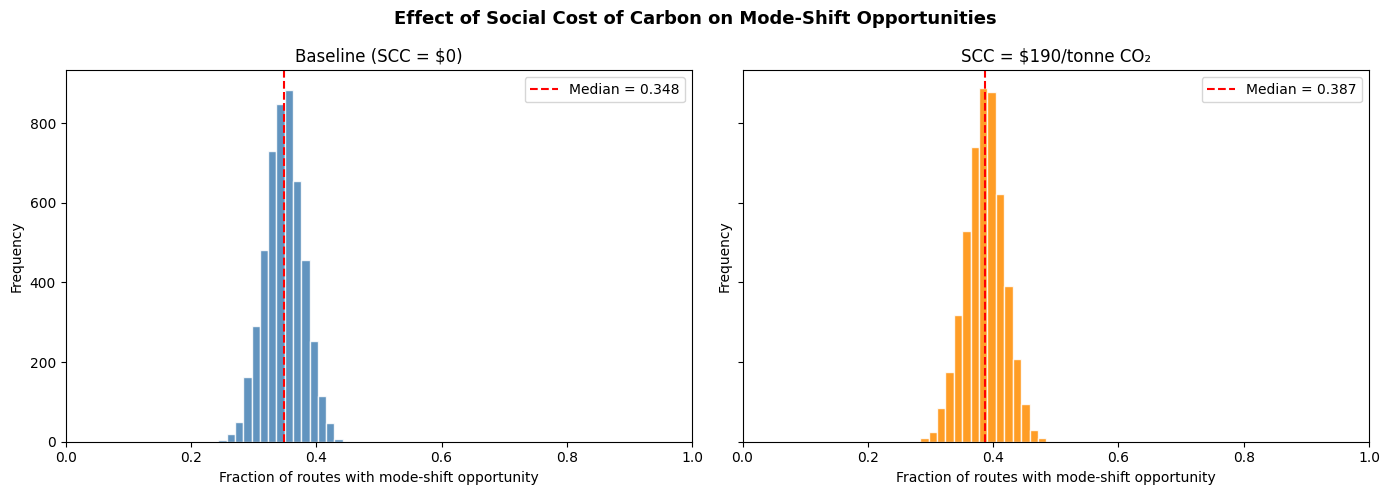

Baseline  median mode-shift share: 0.3482
SCC=$190  median mode-shift share: 0.3873


In [46]:
# Side-by-side MC distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, results, label, color in zip(
    axes,
    [HTS2_mc_results, HTS2_scc_mc_results],
    ['Baseline (SCC = $0)', f'SCC = ${SCC}/tonne CO₂'],
    ['steelblue', 'darkorange'],
):
    ax.hist(results['mode_shift_opp_share'], bins=15, color=color, alpha=0.85, edgecolor='white')
    med = results['mode_shift_opp_share'].median()
    ax.axvline(med, color='red', linestyle='--', label=f'Median = {med:.3f}')
    ax.set_xlabel('Fraction of routes with mode-shift opportunity')
    ax.set_ylabel('Frequency')
    ax.set_title(label)
    ax.set_xlim(0, 1)
    ax.legend()

plt.suptitle('Effect of Social Cost of Carbon on Mode-Shift Opportunities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Thesis_Plots/scc_mc_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Baseline  median mode-shift share: {HTS2_mc_results['mode_shift_opp_share'].median():.4f}")
print(f"SCC=${SCC}  median mode-shift share: {HTS2_scc_mc_results['mode_shift_opp_share'].median():.4f}")


In [47]:
# ── Reconstruct both scenarios from the SAME baseline median simulation ──
#
# Monotonicity requires a fixed-parameter comparison: same av_cost, mar_cost,
# mar_speed, and tariff error draw — only the SCC value changes.  If we
# instead pick each scenario's own median sim, we get different stochastic
# draws and there is no guarantee that the SCC draw flags more routes.
#
# baseline_air_cheaper_median was already built in cell 28 using the
# baseline median sim.  We reuse those exact same parameters here.

scc_air_cheaper_median = functions.total_transport_cost(
    all_non_zeronan,
    av_cost=median_params['av_cost'],
    mar_cost=median_params['mar_cost'],
    mar_speed=median_params['mar_speed'],
    av_speed=800,
    error_draws=error_draws_baseline,   # identical draw to baseline
    scc=SCC,
)

print(f"Baseline  mode-shift share (this sim): {baseline_air_cheaper_median['mode_shift_opportunity'].mean():.4f}")
print(f"SCC=${SCC}  mode-shift share (same sim): {scc_air_cheaper_median['mode_shift_opportunity'].mean():.4f}")


Baseline  mode-shift share (this sim): 0.3482
SCC=$190  mode-shift share (same sim): 0.3887


In [48]:
# ── Group by HTS and compare excess (shiftable) emissions ───────────────
# 'Excess emissions' = aviation emissions for rows flagged as mode-shift
# opportunities.  Because SCC flags MORE rows, the SCC case will always
# have >= excess emissions than baseline — the SCC case INCREASES shiftable
# emissions.  The delta below measures that additional flagged potential.

def excess_emissions_by_hts(df_scenario):
    """Aviation (and hypothetical maritime) emissions for mode-shift flagged rows."""
    return (
        df_scenario[df_scenario['mode_shift_opportunity'] == 1]
        .groupby('hts_num')[['MtCO2eq_aviation', 'hypo_MtCO2eq_maritime']]
        .sum()
    )

baseline_excess = excess_emissions_by_hts(baseline_air_cheaper_median).rename(
    columns={'MtCO2eq_aviation': 'baseline_av_MtCO2',
             'hypo_MtCO2eq_maritime': 'baseline_hypo_mar_MtCO2'})
scc_excess = excess_emissions_by_hts(scc_air_cheaper_median).rename(
    columns={'MtCO2eq_aviation': 'scc_av_MtCO2',
             'hypo_MtCO2eq_maritime': 'scc_hypo_mar_MtCO2'})

excess_comparison = (
    pd.concat([baseline_excess, scc_excess], axis=1)
    .fillna(0)
    .reset_index()
)
excess_comparison['hts_name'] = excess_comparison['hts_num'].map(hts_codes)

# SCC flags more rows → scc_av_MtCO2 >= baseline_av_MtCO2 for every HTS chapter.
# 'additional_flagged' is the extra shiftable emissions the SCC price unlocks.
excess_comparison['additional_flagged_MtCO2'] = (
    excess_comparison['scc_av_MtCO2'] - excess_comparison['baseline_av_MtCO2']
)

# Monotonicity check: SCC must never flag FEWER shiftable emissions than baseline
assert (excess_comparison['additional_flagged_MtCO2'] >= -1e-10).all(), (
    'MONOTONICITY VIOLATED: SCC case has LOWER shiftable emissions than baseline '
    'for HTS chapter(s): '
    + str(excess_comparison.loc[excess_comparison['additional_flagged_MtCO2'] < -1e-10, 'hts_num'].tolist())
)

print(f"Baseline  shiftable aviation emissions: {excess_comparison['baseline_av_MtCO2'].sum():.4f} MtCO2eq")
print(f"SCC=${SCC}  shiftable aviation emissions: {excess_comparison['scc_av_MtCO2'].sum():.4f} MtCO2eq")
print(f"Additional emissions flagged by SCC:    {excess_comparison['additional_flagged_MtCO2'].sum():.4f} MtCO2eq")
excess_comparison.sort_values('additional_flagged_MtCO2', ascending=False)


Baseline  shiftable aviation emissions: 9.3663 MtCO2eq
SCC=$190  shiftable aviation emissions: 11.2917 MtCO2eq
Additional emissions flagged by SCC:    1.9254 MtCO2eq


,hts_num,baseline_av_MtCO2,baseline_hypo_mar_MtCO2,scc_av_MtCO2,scc_hypo_mar_MtCO2,hts_name,additional_flagged_MtCO2
82,84,0.649734,0.005219,1.036022,0.007497,Mechanical Machinery,3.862883e-01
85,87,0.147364,0.001252,0.378154,0.003687,Vehicles and Parts,2.307896e-01
60,61,0.310624,0.002220,0.517048,0.003606,Apparel (Knitted),2.064241e-01
2,3,0.231993,0.001895,0.368485,0.003046,Fish,1.364922e-01
72,73,0.164559,0.001362,0.270608,0.002265,Iron/Steel Articles,1.060488e-01
...,...,...,...,...,...,...,...
15,16,0.012882,0.000092,0.012888,0.000092,Meat Preparations,6.384787e-06
25,26,0.004972,0.000047,0.004974,0.000047,Ores,1.772372e-06
49,50,0.000982,0.000007,0.000982,0.000007,Silk,1.769427e-07
13,14,0.001464,0.000012,0.001464,0.000012,Vegetable Products,0.000000e+00


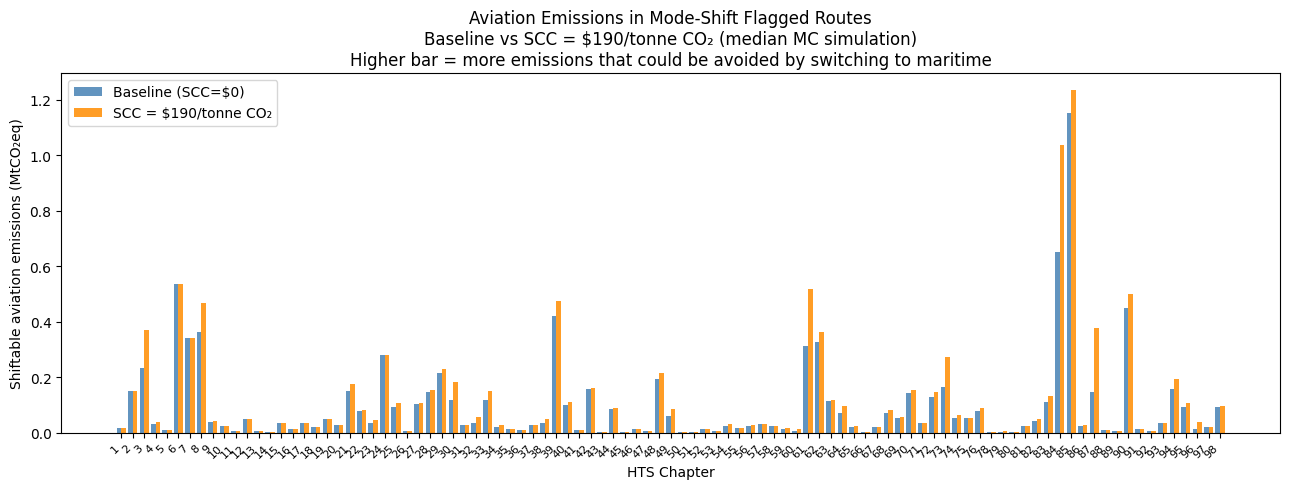

In [49]:
# ── Plot: Shiftable aviation emissions by HTS — baseline vs SCC ──────────
fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(excess_comparison))
width = 0.4

ax.bar(x - width/2, excess_comparison['baseline_av_MtCO2'], width,
       label='Baseline (SCC=$0)', color='steelblue', alpha=0.85)
ax.bar(x + width/2, excess_comparison['scc_av_MtCO2'], width,
       label=f'SCC = ${SCC}/tonne CO₂', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(excess_comparison['hts_num'].astype(str), rotation=45, ha='right', fontsize=8)
ax.set_xlabel('HTS Chapter')
ax.set_ylabel('Shiftable aviation emissions (MtCO₂eq)')
ax.set_title(
    f'Aviation Emissions in Mode-Shift Flagged Routes\n'
    f'Baseline vs SCC = ${SCC}/tonne CO₂ (median MC simulation)\n'
    f'Higher bar = more emissions that could be avoided by switching to maritime'
)
ax.legend()
plt.tight_layout()
plt.savefig(f'Thesis_Plots/scc_shiftable_emissions_scc{SCC}.png', dpi=200, bbox_inches='tight')
plt.show()


In [39]:
#trump and obama numbers

trump_mc_results = functions.monte_carlo_transport_cost(all_non_zeronan, n_sims=5000, scc=3)
obama_mc_results = functions.monte_carlo_transport_cost(all_non_zeronan, n_sims=5000, scc=51)

In [40]:
print(trump_mc_results['mode_shift_opp_share'].median())
print(obama_mc_results['mode_shift_opp_share'].median())

0.3483099239870119
0.35876637513840337


## Other Figures for General Understanding/Flash Talk

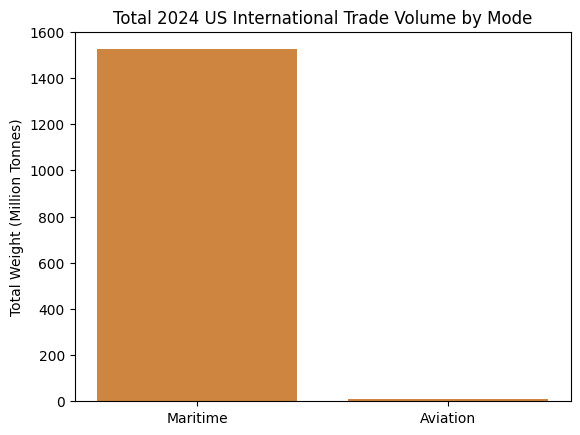

In [51]:
total_av_wgt = all_emissions['AIR_WGT_T'].sum() / 1e6
total_mar_wgt = all_emissions['VES_WGT_T'].sum() / 1e6

plt.bar(['Maritime', 'Aviation'], [total_mar_wgt, total_av_wgt], color='peru')
plt.ylabel('Total Weight (Million Tonnes)')
plt.title('Total 2024 US International Trade Volume by Mode')
plt.show()

In [52]:
print(tot_mar_em_mt)
print(tot_av_em_mt)

134.43557031706243
52.96041817237866


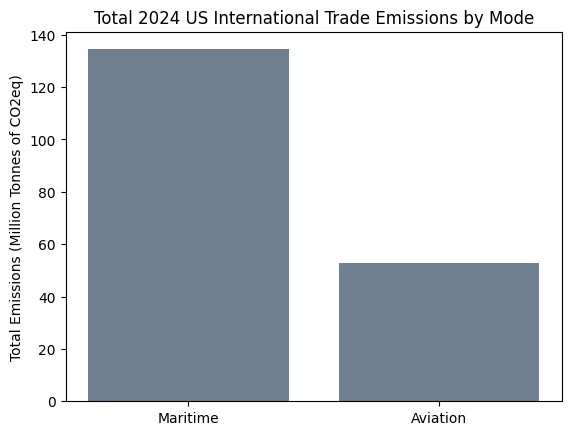

In [53]:
plt.bar(['Maritime', 'Aviation'], [tot_mar_em_mt, tot_av_em_mt], color='slategrey')
plt.ylabel('Total Emissions (Million Tonnes of CO2eq)')
plt.title('Total 2024 US International Trade Emissions by Mode')
plt.show()

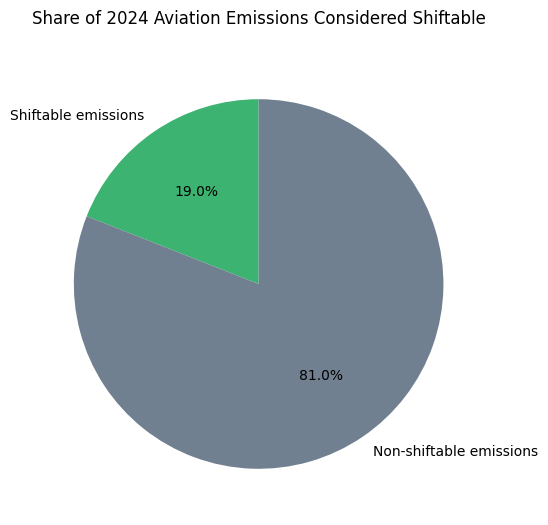

In [54]:


# Calculate non-shiftable portion
non_shiftable = tot_av_em_mt - p50

# Data for pie chart
sizes = [p50, non_shiftable]
labels = ['Shiftable emissions', 'Non-shiftable emissions']

# Create pie chart
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    startangle=90,
    colors=['mediumseagreen', 'slategrey']
)

ax.set_title('Share of 2024 Aviation Emissions Considered Shiftable\n')

plt.show()